# Milestone Project 2: SkimLit ⚓  

```
The purpose of this notebook is to build a NLP model to make reading medical abstracts easier.
```  


## Get data

https://github.com/Franck-Dernoncourt/pubmed-rct

In [28]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 10.38 MiB/s, done.
Resolving deltas: 100% (15/15), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [29]:
# Check what files are in PubMed_20K dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/
!ls pubmed-rct/PubMed_20k_RCT/

dev.txt  test.txt  train.txt
dev.txt  test.txt  train.txt


In [30]:
# Start our experiments using the 20K dataset with numbers replaced by "@" sign
data_dir ="/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign"

In [31]:
# Check all of the filenames in the target directory
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames


['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtrain.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtest.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signdev.txt']

## Preprocess data

Let's write a function to read in all of the lines of a target text file.  

https://realpython.com/read-write-files-python/

In [32]:
def get_lines(filename):
  """
  Reads filename (a text filenma) and returns a list of the lines as a list.

  Args:
    filename (str): target text filename.

  Returns:
    A list of lines contained in the text file.
  """
  with open(filename, "r") as f:
    return f.readlines()

In [33]:
# Let's read in the training lines
train_lines = get_lines(data_dir + "/train.txt")
train_lines[:25]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [34]:
len(train_lines)

210040

Let's think about how we want our data look ...  

How I think our data would be best represented.  


```[{'line_number': 0,
  'target': 'BACKGROUND',
  'text': 'Emotional eating is associated with overeating and the development of obesity .\n'
  'total_lines': 11},
  ...]
  ```


In [35]:
def preprocessing_text_line_numbers(filename):
  """
  Returns a list of dictionaries of abstract line data.

  Takes in filenma, reads it contents and sorts through each line,
  extracting things like the target label, the text of the sentence,
  how many sentences are in the current abstract and what sentence
  number the target line is.
  """
  input_lines = get_lines(filename) # get all lines from filename
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create an empty list of abstract

  # loop through each in traget file
  for line in input_lines:
    if line.startswith("###"): # check to see if the is an ID line
      abstract_id = line
      abstract_lines = "" # reset the abstract string if the line is an ID line
    elif line.isspace(): # check to see if the line is a new line (\n)
      abstract_line_split = abstract_lines.splitlines() # split the abstract string into a list of lines

      # Iterate through each line in a single abstract and count them at the same time
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {}
        target_text_split = abstract_line.split("\t") # split the target from the text
        line_data["target"] = target_text_split[0] # get the target
        line_data["text"] = target_text_split[1].strip().lower() # get the text
        line_data["line_number"] = abstract_line_number # get the line number
        line_data["total_lines"] = len(abstract_line_split) -1 # get the total number of lines
        abstract_samples.append(line_data) # add the line data to the abstract samples list

    else:
      abstract_lines += line # add the line to the abstract string

  return abstract_samples

In [36]:
# Get data from file and preprocess it
%%time
train_samples = preprocessing_text_line_numbers(data_dir + "/train.txt")
val_samples = preprocessing_text_line_numbers(data_dir + "/dev.txt") # dev = val
test_samples = preprocessing_text_line_numbers(data_dir + "/test.txt")

CPU times: user 327 ms, sys: 76.7 ms, total: 404 ms
Wall time: 405 ms


In [37]:
len(train_samples), len(val_samples), len(test_samples)

(180040, 30212, 30135)

In [38]:
# Check some abstract of our training data
training_samples = train_samples[0:10]
training_samples

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [39]:
import pandas as pd

In [40]:
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

In [41]:
train_df.head(15)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [42]:
# Distributions of labels in training data
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


<Axes: ylabel='Frequency'>

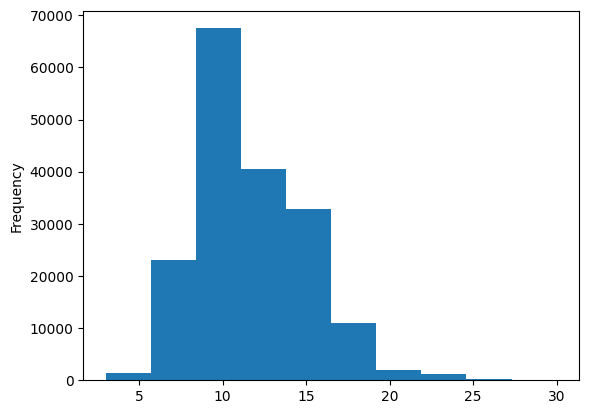

In [43]:
# Let's check the length of different lines
train_df.total_lines.plot.hist()

### Get lists of sentences

In [44]:
train_sentences = train_df["text"].to_list()
val_sentences = val_df["text"].to_list()
test_sentences = test_df["text"].to_list()

In [45]:
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [46]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

## Make numeric labels (ML models require numeric labels)

In [47]:
# One hot encode labels
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df[["target"]])
val_labels_one_hot = one_hot_encoder.transform(val_df[["target"]])
test_labels_one_hot = one_hot_encoder.transform(test_df[["target"]])

In [48]:
train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

### Label encode labels

In [49]:
# Extract labels ("target", columns) and encode them into integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"])
val_labels_encoded = label_encoder.transform(val_df["target"])
test_labels_encoded = label_encoder.transform(test_df["target"])

In [50]:
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [51]:
# Get class names and number of classes from LabelEncoder instance
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Starting a series of modelling experiments...  

As usual, we're going to be trying out bunch of different models and seeing which one works best.  

And as always, we're going to start with a baseline (`TF-IDF Multinomial Naive Bayes classifier`) .  

https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/



## Model 0: Getting a baseline

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling pipeline
model_0 = Pipeline([
  ("tfidf", TfidfVectorizer()), # convert words to numbers using tfidf
  ("clf", MultinomialNB()) # model the text
])

# Fithe pipeline to the training data
model_0.fit(train_sentences,
            train_labels_encoded)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [53]:
# Evaluate
model_0_score = model_0.score(val_sentences, val_labels_encoded)
model_0_score

0.7218323844829869

In [54]:
# Make predictions
baseline_preds = model_0.predict(val_sentences)
baseline_preds[:20]

array([4, 1, 3, 2, 2, 2, 2, 2, 4, 4, 0, 4, 1, 1, 2, 2, 4, 1, 4, 4])

In [55]:
# Convert into labels
baseline_labels = label_encoder.inverse_transform(baseline_preds)
baseline_labels[:20]

array(['RESULTS', 'CONCLUSIONS', 'OBJECTIVE', 'METHODS', 'METHODS',
       'METHODS', 'METHODS', 'METHODS', 'RESULTS', 'RESULTS',
       'BACKGROUND', 'RESULTS', 'CONCLUSIONS', 'CONCLUSIONS', 'METHODS',
       'METHODS', 'RESULTS', 'CONCLUSIONS', 'RESULTS', 'RESULTS'],
      dtype=object)

### Download helper function

In [56]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-06-03 19:08:38--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-03 19:08:38 (97.1 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [57]:
from helper_functions import calculate_results

In [58]:
baseline_score = calculate_results(y_true=val_labels_encoded,
                                  y_pred=baseline_preds)
baseline_score

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

In [60]:
print(classification_report(y_true=val_labels_encoded,
                            y_pred=baseline_preds))

              precision    recall  f1-score   support

           0       0.66      0.49      0.56      3449
           1       0.65      0.59      0.61      4582
           2       0.72      0.87      0.79      9964
           3       0.75      0.14      0.23      2376
           4       0.76      0.86      0.81      9841

    accuracy                           0.72     30212
   macro avg       0.71      0.59      0.60     30212
weighted avg       0.72      0.72      0.70     30212



In [61]:
confusion_matrix(y_true=val_labels_encoded,
                 y_pred=baseline_preds)

array([[1683,  794,  694,   97,  181],
       [ 244, 2687,  432,    5, 1214],
       [ 116,   75, 8670,    7, 1096],
       [ 505,  422,  978,  325,  146],
       [  20,  181, 1196,    1, 8443]])

## Preparing text into numeric format

We need vectorization and embedding layers to build deep learning model for text data.  



In [62]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [63]:
# How long is each sentence on average?
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len, np.min(sent_lens), np.max(sent_lens)


(np.float64(26.338269273494777), np.int64(1), np.int64(296))

(array([4.2075e+04, 8.3771e+04, 3.6877e+04, 1.0945e+04, 3.9310e+03,
        1.4450e+03, 5.6000e+02, 2.2600e+02, 1.0100e+02, 4.5000e+01,
        2.0000e+01, 1.2000e+01, 9.0000e+00, 1.0000e+01, 6.0000e+00,
        2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([  1.  ,  15.75,  30.5 ,  45.25,  60.  ,  74.75,  89.5 , 104.25,
        119.  , 133.75, 148.5 , 163.25, 178.  , 192.75, 207.5 , 222.25,
        237.  , 251.75, 266.5 , 281.25, 296.  ]),
 <BarContainer object of 20 artists>)

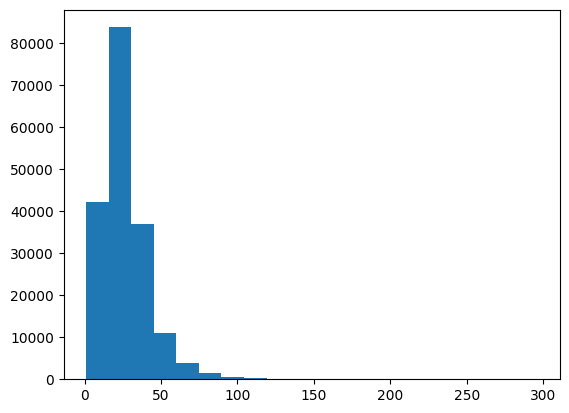

In [64]:
# Distributions
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=20)

In [65]:
# How long of a sentence lenght covers 95% of examples
output_seq_len = int(np.ceil(np.percentile(sent_lens, 95)))
output_seq_len

55

In [66]:
train_sentences[np.argmax(sent_lens)]

'patients in the antegrade group achieved better outcomes than patients in the retrograde group for all clinical parameters at @ months postoperatively ( rom : antegrade median @ -lsb- range , @-@ -rsb- versus retrograde @ -lsb- range , @-@ -rsb- , difference of medians @ , p < @ ; vas : antegrade median of @ -lsb- range , @-@ -rsb- versus retrograde @ -lsb- range , @-@ -rsb- , difference of medians @ , p < @ ; grip strength : antegrade median @ % -lsb- range , @ % -@ % -rsb- versus retrograde @ % -lsb- range , @ % -@ % -rsb- , differences of medians @ % , p < @ ; dash : antegrade median @ -lsb- range , @-@ @ -rsb- versus retrograde @ -lsb- range , @-@ @ -rsb- , difference of medians @ , p < @ ) , but these differences , with the numbers available , were not observed at @ months postoperatively for any clinical parameters ( rom : antegrade median @ -lsb- range , @-@ -rsb- versus retrograde @ -lsb- range , @-@ -rsb- , difference of medians @ , p = @ ; vas : antegrade median @ -lsb- rang

In [67]:
train_sentences[np.argmin(sent_lens)]

'i.'

### Create text vectorizer layer

We want to make a layer which maps our texts from words to number.  

```
Look at the article to define vocabulary size:  
```
https://arxiv.org/pdf/1710.06071

In [68]:
max_tokens = 68000

In [69]:
from tensorflow.keras.layers import TextVectorization

In [70]:
text_vectorizer = TextVectorization(max_tokens=max_tokens,
                                    output_mode="int",
                                    output_sequence_length=output_seq_len)

In [71]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [72]:
import random

In [73]:
# Test out text vectorizer on random sentences
target_sentence = random.choice(train_sentences)
print(f"Text:\n{target_sentence}\n")
print(f"Length of text with space: {len(target_sentence.split())}\n")
print(f"Vectorized text:\n{text_vectorizer([target_sentence])}")


Text:
the number of routine antenatal visits provided to low risk nulliparous women has been reduced in the uk , acknowledging this change in care may result in women being less satisfied with their care and having poorer psychosocial outcomes .

Length of text with space: 40

Vectorized text:
[[    2   154     4   633  2650   620   485     6   220    73  6620    90
    139   167   191     5     2  1404 17596    23   133     5    77    91
    692     5    90   571   211  2766     7   120    77     3   956  2908
   1391    75     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]


In [74]:
# How many words in our training vocabulary
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocab: {len(rct_20k_text_vocab)}")
print(f"Top 5 common words: {rct_20k_text_vocab[:5]}")
print(f"Bottom 5 common words: {rct_20k_text_vocab[-5:]}")

Number of words in vocab: 64841
Top 5 common words: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Bottom 5 common words: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [75]:
# Get the config of our text vectorizer
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

### Create custom text embedding

In [76]:
token_embed = layers.Embedding(input_dim=len(rct_20k_text_vocab),
                               output_dim=128,
                               mask_zero=True,
                               name="token_embedding")


In [77]:
# Show example embedding
print(f"Sentence before vectorization:\n {target_sentence} \n")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"Sentence after vectorization:\n {vectorized_sentence} \n")
embedded_sentence = token_embed(vectorized_sentence)
print(f"Embedded sentence:\n {embedded_sentence}")
print(f"Embedded sentence shape:\n {embedded_sentence.shape}")

Sentence before vectorization:
 the number of routine antenatal visits provided to low risk nulliparous women has been reduced in the uk , acknowledging this change in care may result in women being less satisfied with their care and having poorer psychosocial outcomes . 

Sentence after vectorization:
 [[    2   154     4   633  2650   620   485     6   220    73  6620    90
    139   167   191     5     2  1404 17596    23   133     5    77    91
    692     5    90   571   211  2766     7   120    77     3   956  2908
   1391    75     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]] 

Embedded sentence:
 [[[ 0.02611203  0.04902157 -0.04218131 ...  0.04034993  0.03491061
    0.00036588]
  [-0.04986967 -0.04351395 -0.02873403 ...  0.04635333  0.03599311
   -0.01734322]
  [-0.02327926 -0.03361909 -0.01613821 ... -0.00073558 -0.00605946
    0.02884484]
  ...
  [ 0.0038972   0.03140534 -0.01778016 ... -0.01915146  0.03165871
   -0.008

## Creating datasets (making sure our data loads as fast as possible)

We're going to setup our data to run as fast as possible with TensorFlow tf.data API, many of the steps here are discussed at length in these resources:
* https://www.tensorflow.org/guide/data  
* https://www.tensorflow.org/guide/data_performance  


In [78]:
# Tunr our data into TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
val_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

In [79]:
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>

In [80]:
train_labels_one_hot.shape, train_labels_one_hot[0]

((180040, 5), array([0., 0., 0., 1., 0.]))

In [81]:
# Take the TensorSliceDataset's and turn them into prefected datasets
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [82]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

## Model 1: Conv1D with token embedding

In [83]:
num_classes

5

In [84]:
# Crete 1D conv model to process sequences
inputs = layers.Input(shape=(1,), dtype=tf.string)

text_vectors = text_vectorizer(inputs)
token_embeddings = token_embed(text_vectors)

x = layers.Conv1D(filters=64,
                        kernel_size=5,
                        padding="same",
                        activation="relu")(token_embeddings)

x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model_1 = tf.keras.Model(inputs, outputs, name="model_1_conv1d")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [85]:
# Compile the model
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [86]:
model_1.summary()

Model: "model_1_conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
len(train_dataset), len(train_sentences)

(5627, 180040)

In [88]:
5627 * 32

180064

In [89]:
# Fit the model
history_model_1 = model_1.fit(train_dataset,
                              steps_per_epoch=int(0.1 * len(train_dataset)),
                              epochs=3,
                              validation_data=val_dataset,
                              validation_steps=int(0.1 * len(val_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6373 - loss: 0.9244 - val_accuracy: 0.7347 - val_loss: 0.7040
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7483 - loss: 0.6735 - val_accuracy: 0.7626 - val_loss: 0.6477
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7732 - loss: 0.6254 - val_accuracy: 0.7836 - val_loss: 0.6002


In [252]:
# Evaluate on whole validataion dataset
model_1.evaluate(val_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7873 - loss: 0.5958


[0.5958467721939087, 0.7873030304908752]

In [90]:
# Make preidictions  (our model predicts prediction probabilities for each class)
model_1_pred_probs = model_1.predict(val_dataset)
model_1_pred_probs, model_1_pred_probs.shape

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(array([[4.0191257e-01, 1.6578655e-01, 1.2982479e-01, 2.6444924e-01,
         3.8026847e-02],
        [4.3427506e-01, 3.0413416e-01, 9.0886289e-03, 2.4505015e-01,
         7.4520605e-03],
        [1.4250349e-01, 8.0273366e-03, 2.6724341e-03, 8.4674424e-01,
         5.2482457e-05],
        ...,
        [3.6508641e-06, 5.9543079e-04, 8.2246470e-04, 3.0504168e-06,
         9.9857545e-01],
        [4.9345974e-02, 5.1161808e-01, 7.7436425e-02, 5.9387896e-02,
         3.0221161e-01],
        [2.3385343e-01, 5.8549428e-01, 5.7639491e-02, 5.5308226e-02,
         6.7704611e-02]], dtype=float32),
 (30212, 5))

In [91]:
# Convert prediction probs to classes
model_1_preds = tf.argmax(model_1_pred_probs, axis=1)
model_1_preds, model_1_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>,
 TensorShape([30212]))

In [92]:
class_names

array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
      dtype=object)

In [93]:
# Calculate model_1 results
model_1_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 78.49860982391102,
 'precision': 0.7810005475679709,
 'recall': 0.7849860982391103,
 'f1': 0.7822779845115971}

In [257]:
print(classification_report(val_labels_encoded, model_1_preds))

              precision    recall  f1-score   support

           0       0.64      0.52      0.57      3449
           1       0.69      0.73      0.71      4582
           2       0.86      0.87      0.87      9964
           3       0.59      0.60      0.60      2376
           4       0.85      0.87      0.86      9841

    accuracy                           0.79     30212
   macro avg       0.73      0.72      0.72     30212
weighted avg       0.78      0.79      0.79     30212



In [258]:
confusion_matrix(val_labels_encoded, model_1_preds)

array([[1786,  627,  282,  710,   44],
       [ 393, 3323,  175,  118,  573],
       [  95,  171, 8704,  139,  855],
       [ 505,  239,  178, 1430,   24],
       [  26,  475,  780,   17, 8543]])

In [94]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False, figsize=(10, 8), cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm_display = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        title = "Normalized Confusion Matrix"
        fmt = ".2f"
    else:
        cm_display = cm
        title = "Confusion Matrix"
        fmt = "d"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_display, cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))

    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    plt.colorbar(im, ax=ax)

    threshold = cm_display.max() / 2

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            value = cm_display[i, j]
            text = format(value, fmt) if normalize else format(int(value), fmt)

            ax.text(
                j, i, text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black"
            )

    plt.tight_layout()
    plt.show()

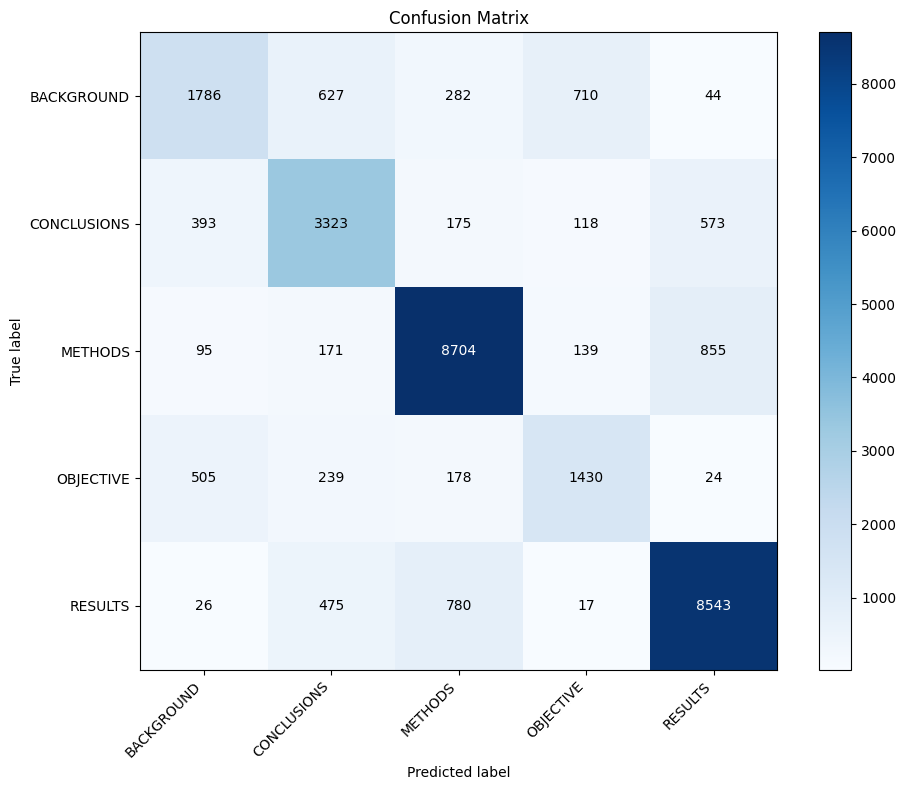

In [260]:
plot_confusion_matrix(
    y_true=val_labels_encoded,
    y_pred=model_1_preds,
    class_names=class_names,
    normalize=False,
    cmap="Blues"
)

## Model 2: Feature extraction with pretrained token embeddings

GloVe Embeddings :   
https://www.geeksforgeeks.org/nlp/glove-word-embedding-in-nlp/  

Universal Sentence Encoder :  
https://www.tensorflow.org/hub/tutorials/semantic_similarity_with_tf_hub_universal_encoder

------------------------------------------------

Now lets use pretrained word embeddings from TensorFlow Hub, more specifically the universal sentence encoder (USE):  
https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2?tfhub-redirect=true

Or more pretrained models, you can look at :  
https://huggingface.co/models  

-------------------------------------------------

The paper originally used GloVe embeddings, however, we're going to stick with later created USE pretrained embeddings.

In [95]:
import numpy as np

In [96]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


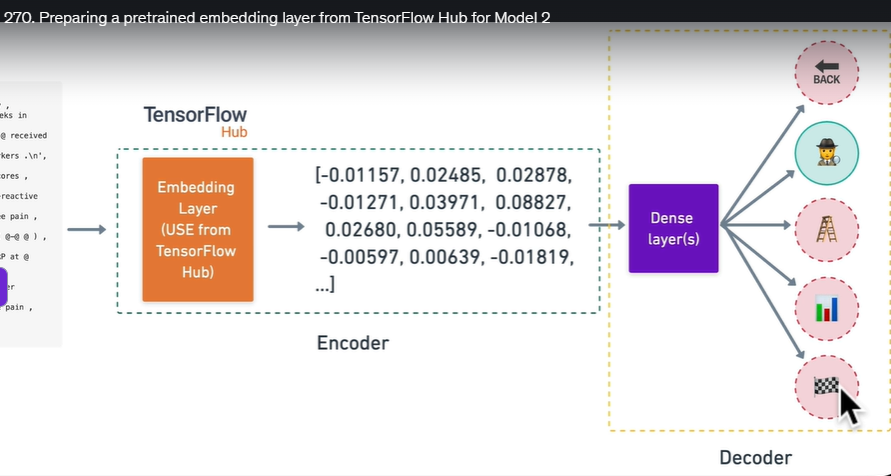

In [176]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/Deep Learning/embedding_layer.png"))

In [97]:
# Download pretrained TensorFlow Hub USE
import tensorflow_hub as hub
tf_hub_embedding_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        trainable=False,
                                        name="universal_sentence_encoder")



In [98]:
# Test out the pretrained embedding on a random sentence
random_train_sentence = random.choice(train_sentences)
print(f"Random sentence:\n {random_train_sentence}")
use_embedding_sentence = tf_hub_embedding_layer([random_train_sentence])
print(f"Sentence after embedding:\n {use_embedding_sentence[0][:36]}")
print(f"Length of sentence after embedding:\n {use_embedding_sentence.shape}")

Random sentence:
 there is a paucity of articles in the surgical literature demonstrating transfer validity ( transfer of training ) .
Sentence after embedding:
 [ 0.08038989  0.02915715  0.04131852  0.00725752  0.06458557  0.03731561
 -0.01559852  0.04045469 -0.0184593   0.01780924  0.0709341  -0.01914639
 -0.01298081  0.07871428 -0.00428303 -0.08210089 -0.01600731 -0.03615025
  0.00224206 -0.05879005 -0.00044637  0.00530062 -0.01167129  0.04633681
  0.00391644  0.02651419  0.04171754 -0.00359793 -0.03454334  0.00386784
 -0.03696553  0.06551413 -0.07044623 -0.07702409  0.01712436 -0.0497035 ]
Length of sentence after embedding:
 (1, 512)


### Building and fitting an NLP feature extraction model using pretrained embeddings TensorFlow Hub

In [99]:
!pip install -q tf-keras

In [100]:
import tensorflow_hub as hub
import tf_keras

# Universal Sentence Encoder layer
tf_hub_embedding_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    input_shape=[],
    dtype=tf.string,
    output_shape=[512],
    trainable=False,
    name="universal_sentence_encoder"
)

model_2 = tf_keras.Sequential([
    tf_hub_embedding_layer,
    tf_keras.layers.Dense(128, activation="relu"),
    tf_keras.layers.Dense(num_classes, activation="softmax")
], name="model_2_pretrained_embedding")

model_2.compile(
    loss="categorical_crossentropy",
    optimizer=tf_keras.optimizers.Adam(),
    metrics=["accuracy"]
)

model_2.summary()

Model: "model_2_pretrained_embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 universal_sentence_encoder  (None, 512)               256797824 
  (KerasLayer)                                                   
                                                                 
 dense (Dense)               (None, 128)               65664     
                                                                 
 dense_1 (Dense)             (None, 5)                 645       
                                                                 
Total params: 256864133 (979.86 MB)
Trainable params: 66309 (259.02 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [267]:
model_2_history = model_2.fit(
    train_dataset,
    steps_per_epoch=int(0.1 * len(train_dataset)),
    epochs=3,
    validation_data=val_dataset,
    validation_steps=int(0.1 * len(val_dataset))
)

Epoch 1/3
562/562 [==============================] - 31s 42ms/step - loss: 0.9124 - accuracy: 0.6541 - val_loss: 0.7975 - val_accuracy: 0.6885
Epoch 2/3
562/562 [==============================] - 10s 17ms/step - loss: 0.7682 - accuracy: 0.7033 - val_loss: 0.7551 - val_accuracy: 0.7048
Epoch 3/3
562/562 [==============================] - 10s 17ms/step - loss: 0.7509 - accuracy: 0.7117 - val_loss: 0.7374 - val_accuracy: 0.7128


In [189]:
# Evaluate on whole validation dataset
model_2.evaluate(val_dataset)

945/945 [==============================] - 13s 13ms/step - loss: 1.6267 - accuracy: 0.1188


[1.6266851425170898, 0.11879386007785797]

In [190]:
model_2_pred_probs = model_2.predict(val_dataset)
model_2_pred_probs, model_2_pred_probs.shape

945/945 [==============================] - 11s 12ms/step


(array([[0.20304503, 0.20618595, 0.19042443, 0.20039073, 0.1999539 ],
        [0.19867556, 0.19336586, 0.19024026, 0.20090556, 0.21681279],
        [0.19154204, 0.21313177, 0.18973069, 0.20757496, 0.19802055],
        ...,
        [0.20582868, 0.20029317, 0.18015026, 0.21160276, 0.20212513],
        [0.19577277, 0.19653307, 0.18611048, 0.2222725 , 0.19931123],
        [0.20439634, 0.20305248, 0.19958106, 0.1949149 , 0.19805522]],
       dtype=float32),
 (30212, 5))

In [191]:
# Convert the prediction probs
model_2_preds = tf.argmax(model_2_pred_probs, axis=1)
model_2_preds, model_2_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([1, 4, 1, ..., 3, 3, 0])>,
 TensorShape([30212]))

In [192]:
# Claulate results
model_2_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_2_preds)
model_2_results

{'accuracy': 11.879385674566398,
 'precision': 0.24242847264665662,
 'recall': 0.11879385674566398,
 'f1': 0.09947545780043911}

In [272]:
model_0.score(val_sentences, val_labels_encoded)

0.7218323844829869

In [273]:
model_1_results

{'accuracy': 78.73030583873958,
 'precision': 0.7843848739916931,
 'recall': 0.7873030583873958,
 'f1': 0.785020094777485}

## Model 3: Conv1D with character embeddings

The paper which we're replicating states they used a combination of token and character embeddings.  

Previously we've token-level embeddings but we'll need to do similar steps or characters if we want to use char-level embeddings.  


### Creating a character-level tokenizer

In [101]:
train_sentences[:5]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .']

In [102]:
list(train_sentences[0])

['t',
 'o',
 ' ',
 'i',
 'n',
 'v',
 'e',
 's',
 't',
 'i',
 'g',
 'a',
 't',
 'e',
 ' ',
 't',
 'h',
 'e',
 ' ',
 'e',
 'f',
 'f',
 'i',
 'c',
 'a',
 'c',
 'y',
 ' ',
 'o',
 'f',
 ' ',
 '@',
 ' ',
 'w',
 'e',
 'e',
 'k',
 's',
 ' ',
 'o',
 'f',
 ' ',
 'd',
 'a',
 'i',
 'l',
 'y',
 ' ',
 'l',
 'o',
 'w',
 '-',
 'd',
 'o',
 's',
 'e',
 ' ',
 'o',
 'r',
 'a',
 'l',
 ' ',
 'p',
 'r',
 'e',
 'd',
 'n',
 'i',
 's',
 'o',
 'l',
 'o',
 'n',
 'e',
 ' ',
 'i',
 'n',
 ' ',
 'i',
 'm',
 'p',
 'r',
 'o',
 'v',
 'i',
 'n',
 'g',
 ' ',
 'p',
 'a',
 'i',
 'n',
 ' ',
 ',',
 ' ',
 'm',
 'o',
 'b',
 'i',
 'l',
 'i',
 't',
 'y',
 ' ',
 ',',
 ' ',
 'a',
 'n',
 'd',
 ' ',
 's',
 'y',
 's',
 't',
 'e',
 'm',
 'i',
 'c',
 ' ',
 'l',
 'o',
 'w',
 '-',
 'g',
 'r',
 'a',
 'd',
 'e',
 ' ',
 'i',
 'n',
 'f',
 'l',
 'a',
 'm',
 'm',
 'a',
 't',
 'i',
 'o',
 'n',
 ' ',
 'i',
 'n',
 ' ',
 't',
 'h',
 'e',
 ' ',
 's',
 'h',
 'o',
 'r',
 't',
 ' ',
 't',
 'e',
 'r',
 'm',
 ' ',
 'a',
 'n',
 'd',
 ' ',
 'w',
 'h',
 'e'

In [103]:
" ".join(list(train_sentences[0]))

't o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .'

In [104]:
# Make function to split sentences into characters
def split_chars(text):
  return " ".join(list(text))

In [105]:
split_chars(random_train_sentence)

't h e r e   i s   a   p a u c i t y   o f   a r t i c l e s   i n   t h e   s u r g i c a l   l i t e r a t u r e   d e m o n s t r a t i n g   t r a n s f e r   v a l i d i t y   (   t r a n s f e r   o f   t r a i n i n g   )   .'

In [106]:
# Split sequence-level data splits into character-level data splits
train_chars = [split_chars(sentence) for sentence in train_sentences]
train_chars[:3]

['t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .',
 'a   t o t a l   o f   @   p a t i e n t s   w i t h   p r i m a r y   k n e e   o a   w e r e   r a n d o m i z e d   @ : @   ;   @   r e c e i v e d   @   m g / d a y   o f   p r e d n i s o l o n e   a n d   @   r e c e i v e d   p l a c e b o   f o r   @   w e e k s   .',
 'o u t c o m e   m e a s u r e s   i n c l u d e d   p a i n   r e d u c t i o n   a n d   i m p r o v e m e n t   i n   f u n c t i o n   s c o r e s   a 

In [107]:
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]

In [108]:
# What's the average character length
char_lens = [len(sentence) for sentence in train_sentences]
avg_char_len = np.mean(char_lens)
avg_char_len, np.min(char_lens), np.max(char_lens)

(np.float64(149.3662574983337), np.int64(1), np.int64(1386))

(array([2.2108e+04, 7.0583e+04, 5.3952e+04, 2.2391e+04, 7.4540e+03,
        2.2350e+03, 8.0200e+02, 2.8700e+02, 1.1800e+02, 4.9000e+01,
        2.9000e+01, 1.3000e+01, 8.0000e+00, 5.0000e+00, 1.0000e+00,
        2.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.00000e+00, 7.02500e+01, 1.39500e+02, 2.08750e+02, 2.78000e+02,
        3.47250e+02, 4.16500e+02, 4.85750e+02, 5.55000e+02, 6.24250e+02,
        6.93500e+02, 7.62750e+02, 8.32000e+02, 9.01250e+02, 9.70500e+02,
        1.03975e+03, 1.10900e+03, 1.17825e+03, 1.24750e+03, 1.31675e+03,
        1.38600e+03]),
 <BarContainer object of 20 artists>)

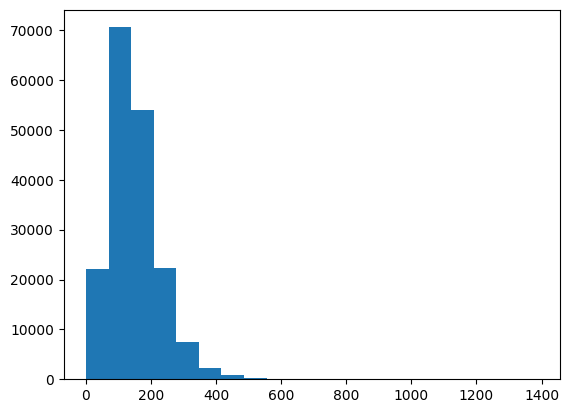

In [109]:
# Distributions
plt.hist(char_lens, bins=20)

In [110]:
output_seq_char_len = int(np.percentile(char_lens, 95))

In [111]:
output_seq_char_len

290

In [112]:
random.choice(train_sentences)

'this trial will be the first implementation trial in the world to evaluate the population impact of the high-risk strategy in prevention and control of cardiovascular disease .'

In [113]:
# Get all keyboard characters
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [114]:
# char-level token vectorizer instance
NUM_CHAR_TOKENS =len(alphabet) + 2 # add 2 for space and OOV (out of vocab)
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,
                                    output_mode="int",
                                    output_sequence_length=output_seq_char_len,
                                    standardize="lower_and_strip_punctuation",
                                    name="char_vectorizer")


In [115]:
NUM_CHAR_TOKENS

70

In [116]:
# Adapt character vectorizer to training character
char_vectorizer.adapt(train_chars)

In [117]:
# Check character vocab stats
char_vectorizer.get_vocabulary()
print(f"Number of characters in vocab: {len(char_vectorizer.get_vocabulary())}")
print(f"Top 5 characters: {char_vectorizer.get_vocabulary()[:5]}")
print(f"Bottom 5 characters: {char_vectorizer.get_vocabulary()[-5:]}")

Number of characters in vocab: 28
Top 5 characters: ['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')]
Bottom 5 characters: [np.str_('k'), np.str_('x'), np.str_('z'), np.str_('q'), np.str_('j')]


In [118]:
# Test out character vectorizer
random_train_chars = random.choice(train_chars)
print(f"Random sentence:\n {random_train_chars} \n")
print(f"Length of random_train_chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"Vectorized random sentence:\n {vectorized_chars} \n")
print(f"Length of vectorized_chars: {len(vectorized_chars[0])}")


Random sentence:
 o f   t h e   @   p a t i e n t s   i n   t h e   s m   g r o u p   ,   @   p a t i e n t s   c o m p l e t e d   @   m o n t h s   o f   f o l l o w - u p   . 

Length of random_train_chars: 64
Vectorized random sentence:
 [[ 7 17  3 13  2 14  5  3  4  2  6  3  9  4  6  3 13  2  9 15 18  8  7 16
  14 14  5  3  4  2  6  3  9 11  7 15 14 12  2  3  2 10 15  7  6  3 13  9
   7 17 17  7 12 12  7 20 16 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  

## Creating a character-level layer


In [127]:
char_embed = layers.Embedding(input_dim=NUM_CHAR_TOKENS,
                              output_dim=25,
                              mask_zero=False,
                              name="char_embed")

In [120]:
# test out character embedding layer
print(f"Charified text:\n {random_train_chars} \n")
char_embed_example = char_embed(char_vectorizer([random_train_chars]))
print(f"Embedded chars (after vectorized and embedded):\n {char_embed_example} \n")
print(f"Embedded chars shape:\n {char_embed_example.shape} \n")

Charified text:
 o f   t h e   @   p a t i e n t s   i n   t h e   s m   g r o u p   ,   @   p a t i e n t s   c o m p l e t e d   @   m o n t h s   o f   f o l l o w - u p   . 

Embedded chars (after vectorized and embedded):
 [[[-0.04761385  0.03442817  0.01764766 ...  0.04462255  0.02863386
   -0.03333376]
  [-0.0360569   0.03127224 -0.04638647 ...  0.00016229 -0.04464171
   -0.01478436]
  [ 0.00352009  0.02390457  0.0169701  ...  0.03566485  0.02439331
    0.04539153]
  ...
  [ 0.01939419  0.03624283 -0.04616808 ... -0.00785904  0.01401987
   -0.04325363]
  [ 0.01939419  0.03624283 -0.04616808 ... -0.00785904  0.01401987
   -0.04325363]
  [ 0.01939419  0.03624283 -0.04616808 ... -0.00785904  0.01401987
   -0.04325363]]] 

Embedded chars shape:
 (1, 290, 25) 



### Building a Conv1D model to fit on character embeddings

In [121]:
# make Conv1D on chars only
inputs = layers.Input(shape=(1,), dtype=tf.string)

char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)

x = layers.Conv1D(filters=64,
                  kernel_size=5,
                  padding="same",
                  activation="relu")(char_embeddings)

x = layers.GlobalMaxPool1D()(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model_3 = tf.keras.Model(inputs, outputs, name="model_3_conv1d_char_embedding")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [295]:
# Compile the model
model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [296]:
model_3.summary()

Model: "model_3_conv1d_char_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_vectorizer                 │ (None, 290)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embed (Embedding)          │ (None, 290, 25)        │         1,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 290, 64)        │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,139 (39.61 KB)

 Trainable params: 10,139 (39.61 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
# Create char level datasets
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset = tf.data.Dataset.from_tensor_slices((test_chars, test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [123]:
train_char_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [299]:
# Fit the model only chars only
model_3_history = model_3.fit(train_char_dataset,
                              steps_per_epoch=int(0.1 * len(train_char_dataset)),
                              epochs=3,
                              validation_data=val_char_dataset,
                              validation_steps=int(0.1 * len(val_char_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4823 - loss: 1.2551 - val_accuracy: 0.5805 - val_loss: 1.0488
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5962 - loss: 1.0164 - val_accuracy: 0.6250 - val_loss: 0.9434
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6378 - loss: 0.9259 - val_accuracy: 0.6666 - val_loss: 0.8696


In [195]:
model_3_pred_probs = model_3.predict(val_char_dataset)
model_3_pred_probs, model_3_pred_probs.shape

 38/945 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


(array([[0.18757397, 0.20005769, 0.19764832, 0.19696356, 0.2177565 ],
        [0.18785381, 0.19884782, 0.19821085, 0.19948743, 0.21560007],
        [0.19070554, 0.19822887, 0.20037828, 0.19522952, 0.21545781],
        ...,
        [0.18731178, 0.19980027, 0.19802438, 0.19635583, 0.2185077 ],
        [0.18670441, 0.19823365, 0.19565934, 0.19897757, 0.22042504],
        [0.19056098, 0.19723451, 0.1998221 , 0.19740576, 0.21497664]],
       dtype=float32),
 (30212, 5))

In [196]:
# Convert probs to labels
model_3_preds = tf.argmax(model_3_pred_probs, axis=1)
model_3_preds, model_3_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([4, 4, 4, ..., 4, 4, 4])>,
 TensorShape([30212]))

In [197]:
# Calculate results
model_3_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_3_preds)
model_3_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'accuracy': 32.57645968489342,
 'precision': 0.43590724780263973,
 'recall': 0.3257645968489342,
 'f1': 0.16013428699967377}

## Model 4: Combining pretrained token embeddings + characters embeddings (hybrid)  

1. Create a token-level ambedding model (similar to `model_1`)  
2. Create a character-level model (similar to `model_3` with a slight modification)  
3. Combine 1 & 2 with a concatenate (`layers.Concatenate`)  
4. Build a series of output layers on top of 3.  
5. Construct a model which takes token and character-level sequences as input and procudes label probabilities as output.  

TensorFlow concatenate layer :  
https://www.tensorflow.org/api_docs/python/tf/keras/layers/Concatenate

Paper Link:  
https://arxiv.org/pdf/1710.06071

In [219]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_hub as hub

class UniversalSentenceEncoderLayer(layers.Layer):
    def __init__(self, hub_url="https://tfhub.dev/google/universal-sentence-encoder/4", **kwargs):
        super().__init__(**kwargs)
        self.hub_url = hub_url
        self.use_layer = hub.KerasLayer(
            self.hub_url,
            trainable=False,
            name="universal_sentence_encoder"
        )

    def call(self, inputs):
        return self.use_layer(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({
            "hub_url": self.hub_url
        })
        return config

In [220]:
# 1. Setup token inputs/model
token_inputs = layers.Input(shape=[], dtype=tf.string, name="token_inputs")

token_embeddings = UniversalSentenceEncoderLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    name="use_embedding_layer"
)(token_inputs)

token_outputs = layers.Dense(128, activation="relu")(token_embeddings)

token_model = tf.keras.Model(
    inputs=token_inputs,
    outputs=token_outputs
)

In [221]:
# 2. Setup character inputs/model
char_inputs = layers.Input(shape=[], dtype=tf.string, name="char_inputs")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(24))(char_embeddings)

char_model = tf.keras.Model(
    inputs=char_inputs,
    outputs=char_bi_lstm
)

In [222]:
# 3. Concatenate token and char inputs
token_char_concat = layers.Concatenate(name="token_char_hybrid")([
    token_model.output,
    char_model.output
])

# 4. Output layers
combined_dropout = layers.Dropout(0.5)(token_char_concat)
combined_dense = layers.Dense(128, activation="relu")(combined_dropout)
final_dropout = layers.Dropout(0.5)(combined_dense)
output_layer = layers.Dense(num_classes, activation="softmax")(final_dropout)

# 5. Construct model
model_4 = tf.keras.Model(
    inputs=[token_model.input, char_model.input],
    outputs=output_layer,
    name="model_4_token_and_char_embeddings"
)

In [223]:
model_4.summary()

Model: "model_4_token_and_char_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_embedding_layer │ (None, 512)       │          0 │ token_inputs[0][… │
│ (UniversalSentence… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │        700 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     65,664 │ use_embedding_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 48)        │      9,600 │ char_embed[1][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 176)       │          0 │ dense_10[0][0],   │
│ (Concatenate)       │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 176)       │          0 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     22,656 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 5)         │        645 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,265 (387.75 KB)

 Trainable params: 99,265 (387.75 KB)

 Non-trainable params: 0 (0.00 B)

In [224]:
token_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_inputs (InputLayer)       │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ use_embedding_layer             │ (None, 512)            │             0 │
│ (UniversalSentenceEncoderLayer) │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,664 (256.50 KB)

 Trainable params: 65,664 (256.50 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
char_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ char_inputs (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_vectorizer                 │ (None, 290)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embed (Embedding)          │ (None, 290, 25)        │         1,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48)             │         9,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,350 (44.34 KB)

 Trainable params: 11,350 (44.34 KB)

 Non-trainable params: 0 (0.00 B)

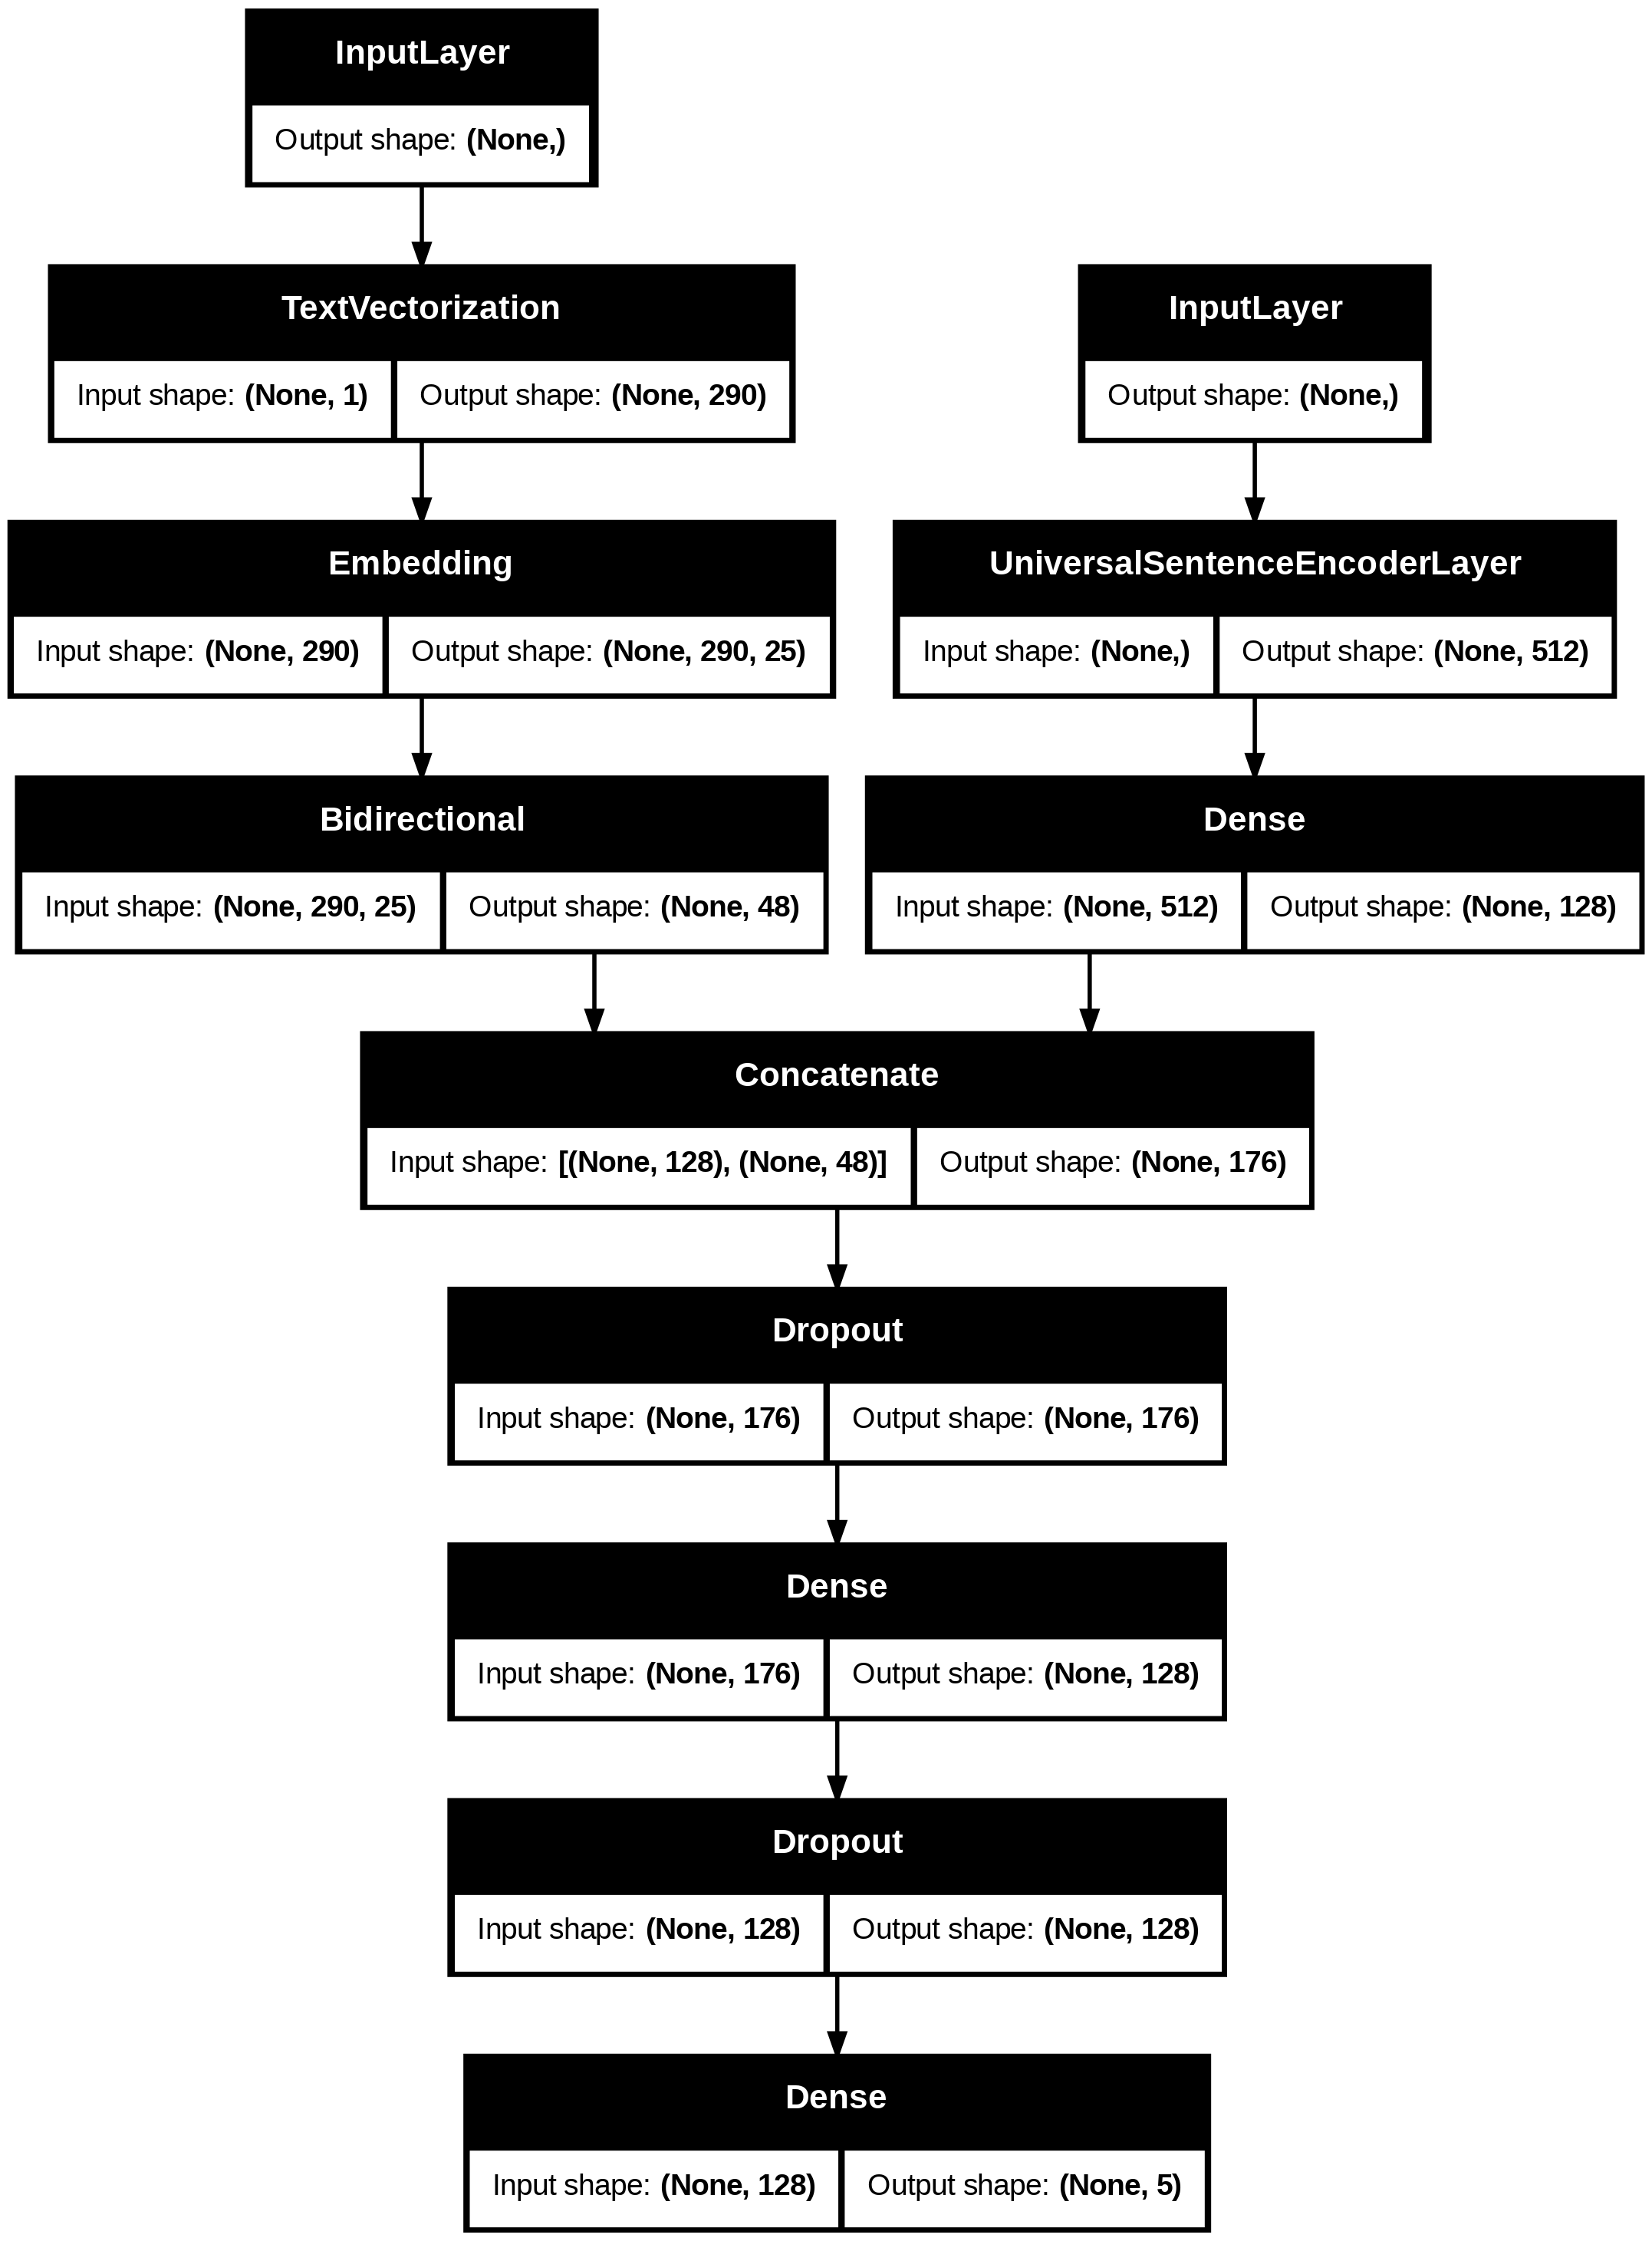

In [226]:
# Plot hybrid token and character model
from keras.utils import plot_model
plot_model(model_4, show_shapes=True)

If you want to check out multimodal deep learning models in industry, you can look at arbnb page:  
https://medium.com/airbnb-engineering/widetext-a-multimodal-deep-learning-framework-31ce2565880c  

It combines text and image modelling.

In [227]:
# Compile token char model
model_4.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

### Combining token and character data into `tf.data Dataset`

In [228]:
# Combine cahrs and tokens into a dataset
train_token_char_data = tf.data.Dataset.from_tensor_slices((train_sentences, train_chars))
train_token_char_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot)
train_token_char_dataset = tf.data.Dataset.zip((train_token_char_data, train_token_char_labels))

val_token_char_data = tf.data.Dataset.from_tensor_slices((val_sentences, val_chars))
val_token_char_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot)
val_token_char_dataset = tf.data.Dataset.zip((val_token_char_data, val_token_char_labels))

test_token_char_data = tf.data.Dataset.from_tensor_slices((test_sentences, test_chars))
test_token_char_labels = tf.data.Dataset.from_tensor_slices(test_labels_one_hot)
test_token_char_dataset = tf.data.Dataset.zip((test_token_char_data, test_token_char_labels))


In [137]:
# Prefetch and batch train data
train_token_char_dataset = train_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_token_char_dataset = val_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_token_char_dataset = test_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

### Fitting a model on token and character-level sequences

In [138]:
# Fit the model on tokens and chars
model_4_history = model_4.fit(train_token_char_dataset,
                              steps_per_epoch=int(0.1 * len(train_token_char_dataset)),
                              epochs=3,
                              validation_data=val_token_char_dataset,
                              validation_steps=int(0.1 * len(val_token_char_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.5985 - loss: 0.9984 - val_accuracy: 0.6945 - val_loss: 0.7898
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.6861 - loss: 0.8101 - val_accuracy: 0.7264 - val_loss: 0.7273
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.7044 - loss: 0.7752 - val_accuracy: 0.7407 - val_loss: 0.6907


In [139]:
# Evaluate on the whole validation dataset
model_4.evaluate(val_token_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.7335 - loss: 0.6977


[0.6976531744003296, 0.7334502935409546]

In [140]:
# Make predictions using the token-character model hybrid
model_4_pred_probs = model_4.predict(val_token_char_dataset)
model_4_pred_probs, model_4_pred_probs.shape

945/945 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step


(array([[4.72579539e-01, 3.47117603e-01, 5.77790290e-03, 1.65735647e-01,
         8.78933817e-03],
        [4.15605128e-01, 3.98754478e-01, 4.43415064e-03, 1.78604335e-01,
         2.60191900e-03],
        [3.07776511e-01, 2.15719581e-01, 5.01694642e-02, 3.83470148e-01,
         4.28642295e-02],
        ...,
        [3.71423346e-04, 6.11471944e-03, 6.41540512e-02, 1.16477866e-04,
         9.29243267e-01],
        [1.49668483e-02, 6.12212978e-02, 2.60295331e-01, 5.45041589e-03,
         6.58066094e-01],
        [2.78213739e-01, 4.82682854e-01, 1.74092680e-01, 2.17335597e-02,
         4.32771519e-02]], dtype=float32),
 (30212, 5))

In [141]:
# Convert model_4's pred probs into labels
model_4_preds = tf.argmax(model_4_pred_probs, axis=1)
model_4_preds, model_4_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>,
 TensorShape([30212]))

In [142]:
# Get results
model_4_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_4_preds)
model_4_results

{'accuracy': 73.3450284655104,
 'precision': 0.7340943275865708,
 'recall': 0.733450284655104,
 'f1': 0.7305396505392509}

## Model 5: Transfer learning with pretrained token embeddings + character embeddings + positional embedding

In [143]:
train_df

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
...,...,...,...,...
180035,RESULTS,for the absolute change in percent atheroma vo...,7,11
180036,RESULTS,"for pav , a significantly greater percentage o...",8,11
180037,RESULTS,both strategies had acceptable side effect pro...,9,11
180038,CONCLUSIONS,"compared with standard statin monotherapy , th...",10,11


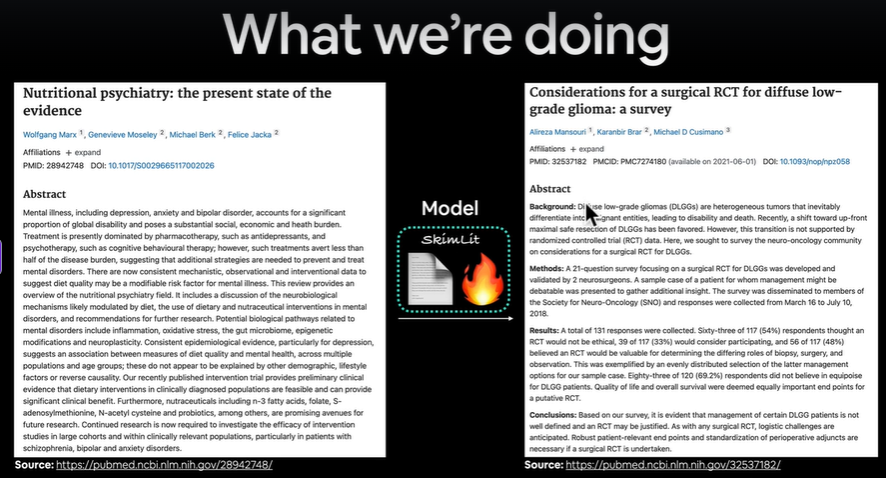

In [338]:
display(Image("/content/drive/MyDrive/Deep Learning/what_we_are_doing.png"))

### Create positional embeddings

In [144]:
# How many different line numbers are there?
train_df["line_number"].value_counts()

,count
line_number,
0,15000
1,15000
2,15000
3,15000
4,14992
5,14949
6,14758
7,14279
8,13346


<Axes: ylabel='Frequency'>

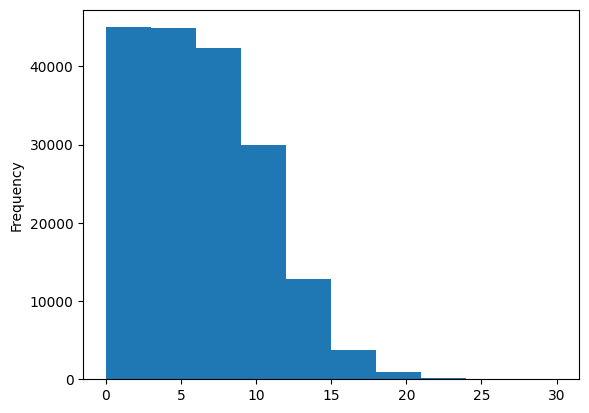

In [145]:
# Check the distributions of line number cloumn
train_df.line_number.plot.hist()

In [146]:
len(train_df["line_number"].value_counts())

31

In [147]:
# Use tensorflow to create one-hot encoded of our line number column
train_line_numbers_one_hot = tf.one_hot(train_df["line_number"].to_numpy(),
                                       depth=15)
train_line_numbers_one_hot

<tf.Tensor: shape=(180040, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [148]:
val_line_numbers_one_hot = tf.one_hot(val_df["line_number"].to_numpy(),
                                     depth=15)
test_line_numbers_one_hot = tf.one_hot(test_df["line_number"].to_numpy(),
                                      depth=15)

Now we've encoded our line numbers feature, let's do the same for our total lines feature...

In [149]:
# How many different number of lines are there?
train_df["total_lines"].value_counts()

,count
total_lines,
11,24468
10,23639
12,22113
9,19400
13,18438
14,14610
8,12285
15,10768
7,7464


In [150]:
len(train_df["total_lines"].value_counts())

27

<Axes: ylabel='Frequency'>

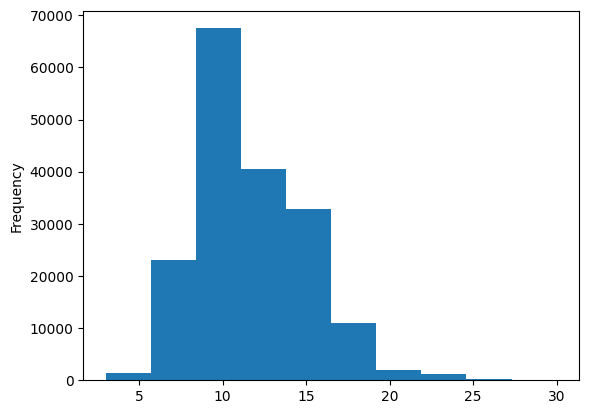

In [151]:
# Plot the distributions of total lines
train_df.total_lines.plot.hist()

In [152]:
# Check the coverage of a "total_lines"  value of 20
np.percentile(train_df.total_lines, 95)


np.float64(18.0)

In [153]:
np.percentile(train_df.total_lines, 98)

np.float64(20.0)

In [154]:
# Use TensorFlow to cfreate one-hot-encoded tensors our "total_lines" feature
train_total_lines_one_hot = tf.one_hot(train_df["total_lines"].to_numpy(),
                                       depth=20)
val_total_lines_one_hot = tf.one_hot(val_df["total_lines"].to_numpy(),
                                     depth=20)
test_total_lines_one_hot = tf.one_hot(test_df["total_lines"].to_numpy(),
                                      depth=20)

### Building a tri-hybrid embedding model

1. Create a token-level model
2. Create a character-level model
3. Create a model for the `line_number` feature
4. Create a model for the `total_lines` feature
5. Combine the outputs of 1 & 2 using `tf.keras.layers.Concatenate`
6. Combine the outputs 3, 4 & 5 using `tf.keras.layers.Concatenate`
7. Create an output layer to accept the tri-hybrid embedding and output label probabilities
8. Combine the inputs 1, 2, 3, 4 and outputs of into a tf.keras.Model


In [155]:
train_line_numbers_one_hot[0].shape, train_line_numbers_one_hot[0].dtype

(TensorShape([15]), tf.float32)

In [156]:
train_total_lines_one_hot[0].shape, train_total_lines_one_hot[0].dtype

(TensorShape([20]), tf.float32)

In [157]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_hub as hub

In [229]:
class UniversalSentenceEncoderLayer(layers.Layer):
    def __init__(self, hub_url="https://tfhub.dev/google/universal-sentence-encoder/4", **kwargs):
        super().__init__(**kwargs)
        self.hub_url = hub_url
        self.use_layer = hub.KerasLayer(
            self.hub_url,
            trainable=False,
            name="universal_sentence_encoder"
        )

    def call(self, inputs):
        return self.use_layer(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({"hub_url": self.hub_url})
        return config

In [230]:
# 1. Token inputs
token_inputs = layers.Input(
    shape=[],
    dtype=tf.string,
    name="token_inputs"
)

token_embeddings = UniversalSentenceEncoderLayer(
    tf_hub_embedding_layer,
    name="use_wrapper"
)(token_inputs)

token_outputs = layers.Dense(
    128,
    activation="relu"
)(token_embeddings)

token_model = tf.keras.Model(
    inputs=token_inputs,
    outputs=token_outputs,
    name="token_model"
)

In [231]:
char_vocab = char_vectorizer.get_vocabulary()
len(char_vocab)

28

In [232]:
char_embed = layers.Embedding(
    input_dim=len(char_vocab),
    output_dim=25,
    mask_zero=False,
    name="char_embed"
)

In [234]:
# 2. Char inputs
char_inputs = layers.Input(
    shape=[],
    dtype=tf.string,
    name="char_inputs"
)

char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)

char_bi_lstm = layers.Bidirectional(
    layers.LSTM(24)
)(char_embeddings)

char_model = tf.keras.Model(
    inputs=char_inputs,
    outputs=char_bi_lstm,
    name="char_model"
)

In [235]:
# 3. Line number model
line_number_inputs = layers.Input(
    shape=(15,),
    dtype=tf.float32,
    name="line_number_input"
)

line_number_outputs = layers.Dense(
    32,
    activation="relu"
)(line_number_inputs)

line_number_model = tf.keras.Model(
    inputs=line_number_inputs,
    outputs=line_number_outputs,
    name="line_number_model"
)

In [236]:
# 4. Total line  model
total_lines_inputs = layers.Input(
    shape=(20,),
    dtype=tf.float32,
    name="total_lines_input"
)

total_lines_outputs = layers.Dense(
    32,
    activation="relu"
)(total_lines_inputs)

total_lines_model = tf.keras.Model(
    inputs=total_lines_inputs,
    outputs=total_lines_outputs,
    name="total_lines_model"
)

In [237]:
# 5. Combine token and char embeddings into hybrid embedding
combined_token_char_embeddings = layers.Concatenate(
    name="token_char_hybrid_embedding"
)([
    token_model.output,
    char_model.output
])

z = layers.Dense(
    256,
    activation="relu"
)(combined_token_char_embeddings)

z = layers.Dropout(0.5)(z)

In [238]:
# 6. Combine positional embeddings with combined token and char embeddings
tribrid_embeddings = layers.Concatenate(
    name="token_char_positional_embedding"
)([
    line_number_model.output,
    total_lines_model.output,
    z
])

In [239]:
# 7. Create output layer
output_layer = layers.Dense(
    5,
    activation="softmax",
    name="output_layer"
)(tribrid_embeddings)

In [240]:
# 8. Put together model with all kinds of inputs
model_5 = tf.keras.Model(
    inputs=[
        line_number_model.input,
        total_lines_model.input,
        token_model.input,
        char_model.input
    ],
    outputs=output_layer,
    name="model_5_tribrid_embedding_model"
)

In [241]:
model_5.summary()

Model: "model_5_tribrid_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_wrapper         │ (None, 512)       │          0 │ token_inputs[0][… │
│ (UniversalSentence… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │        700 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     65,664 │ use_wrapper[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 48)        │      9,600 │ char_embed[1][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid_… │ (None, 176)       │          0 │ dense_13[0][0],   │
│ (Concatenate)       │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_number_input   │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_lines_input   │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256)       │     45,312 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │        512 │ line_number_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │        672 │ total_lines_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_positio… │ (None, 320)       │          0 │ dense_14[0][0],   │
│ (Concatenate)       │                   │            │ dense_15[0][0],   │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 5)         │      1,605 │ token_char_posit… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,065 (484.63 KB)

 Trainable params: 124,065 (484.63 KB)

 Non-trainable params: 0 (0.00 B)

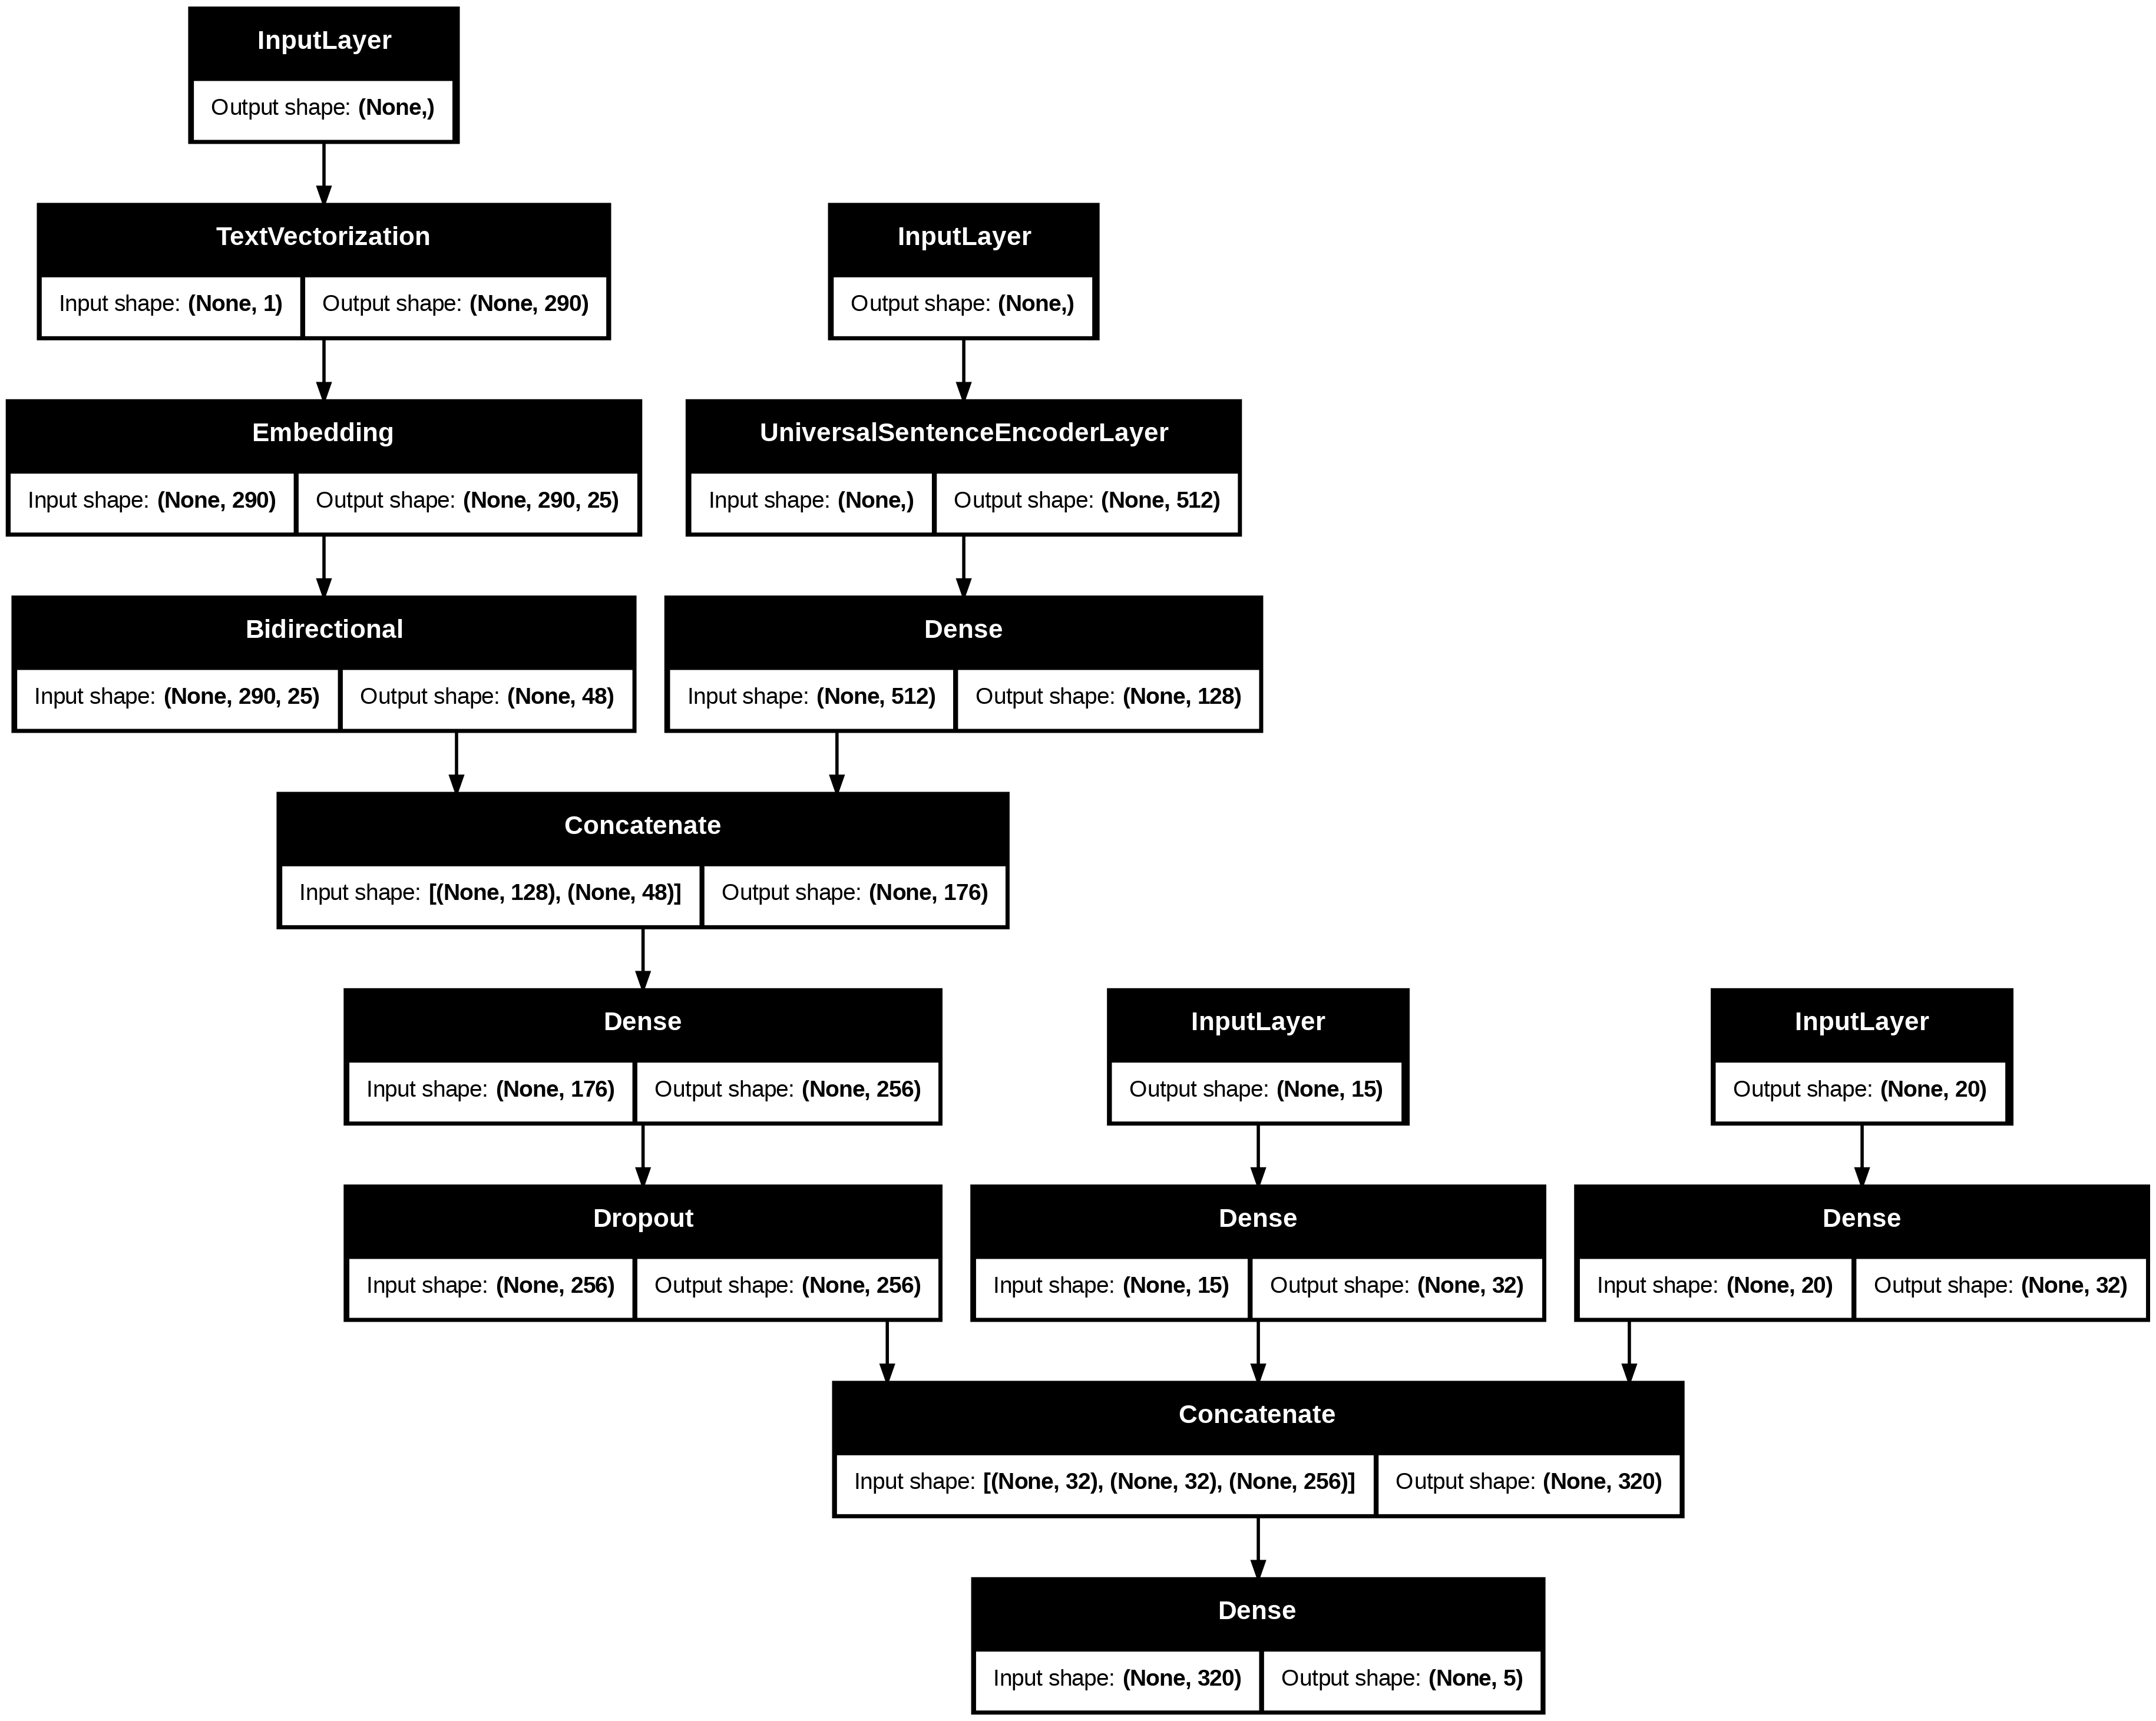

In [242]:
# Plot model_5 to explore it visually...
from tensorflow.keras.utils import plot_model
plot_model(model_5, show_shapes=True)

In [243]:
# Compile token, char and positional embedding model
model_5.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

What is label smoothing?  

for example if our model gets too confident on a single class (e.g. its prediction probability is really high), it may get stuck on that class and not consider other classes.  

Really confident: `[0.0, 0.0, 1.0, 0.0, 0.0]`  

What label smoothing does is it assigns some of the value from the highest prediction probabilities to other classes, in turn, hopefully improvving generalization: `[0.01, 0.01, 0.96, 0.01, 0.01]` etc.  


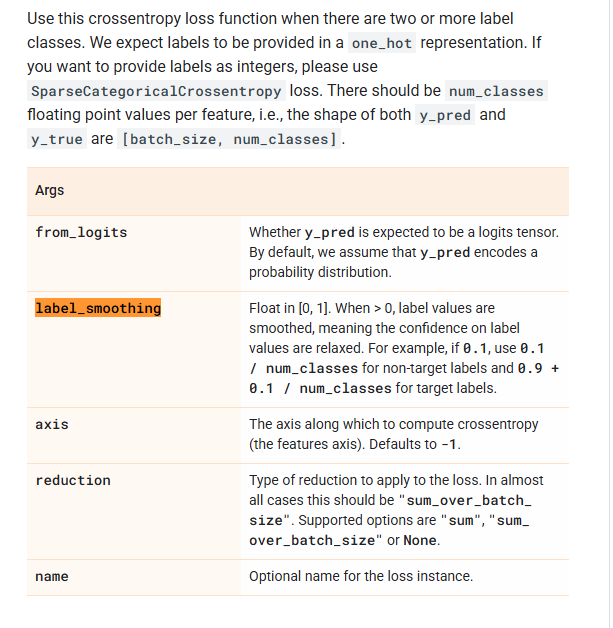

In [177]:
display(Image("/content/drive/MyDrive/Deep Learning/label_smoothing.png"))

### Create trihybrid embedding datasets using tf.data

In [178]:
# Create training and validation datasets (with all kinds od input data)
train_char_token_pos_data = tf.data.Dataset.from_tensor_slices((train_line_numbers_one_hot,
                                                                train_total_lines_one_hot,
                                                                train_sentences,
                                                                train_chars))
train_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot)
train_char_token_pos_dataset = tf.data.Dataset.zip((train_char_token_pos_data, train_char_token_pos_labels))
train_char_token_pos_dataset = train_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

val_char_token_pos_data = tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,
                                                              val_total_lines_one_hot,
                                                              val_sentences,
                                                              val_chars))
val_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot)
val_char_token_pos_dataset = tf.data.Dataset.zip((val_char_token_pos_data, val_char_token_pos_labels))
val_char_token_pos_dataset = val_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

test_char_token_pos_data = tf.data.Dataset.from_tensor_slices((test_line_numbers_one_hot,
                                                               test_total_lines_one_hot,
                                                               test_sentences,
                                                               test_chars))
test_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(test_labels_one_hot)
test_char_token_pos_dataset = tf.data.Dataset.zip((test_char_token_pos_data, test_char_token_pos_labels))
test_char_token_pos_dataset = test_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


In [179]:
# Check input shapes
train_char_token_pos_dataset.element_spec

((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None)),
 TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))

In [181]:
val_char_token_pos_dataset.element_spec

((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None)),
 TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))

### Fitting, evaluating and making predictions with our trihybrid model

In [244]:
history_model_5 = model_5.fit(train_char_token_pos_dataset,
                              steps_per_epoch=int(0.1 * len(train_char_token_pos_dataset)),
                              epochs=3,
                              validation_data=val_char_token_pos_dataset,
                              validation_steps=int(0.1 * len(val_char_token_pos_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.7231 - loss: 1.0976 - val_accuracy: 0.8029 - val_loss: 0.9845
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8122 - loss: 0.9703 - val_accuracy: 0.8265 - val_loss: 0.9536
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.8238 - loss: 0.9522 - val_accuracy: 0.8301 - val_loss: 0.9420


In [245]:
# Make predictions with the char token pos model
model_5_pred_probs = model_5.predict(val_char_token_pos_dataset, verbose=1)
model_5_pred_probs, model_5_pred_probs.shape

945/945 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step


(array([[0.5065371 , 0.10576516, 0.01230827, 0.35308293, 0.02230663],
        [0.5216102 , 0.10000201, 0.03542298, 0.33559638, 0.00736844],
        [0.3254255 , 0.10819286, 0.12577096, 0.37908334, 0.06152723],
        ...,
        [0.03599028, 0.09236148, 0.04303768, 0.03465065, 0.79395986],
        [0.03064971, 0.29412505, 0.09121725, 0.02530481, 0.5587032 ],
        [0.2683844 , 0.5643724 , 0.07053915, 0.0391096 , 0.05759447]],
       dtype=float32),
 (30212, 5))

In [246]:
# Convert pred probs into labels
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)
model_5_preds, model_5_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>,
 TensorShape([30212]))

In [247]:
# Calculate results of char token pos model
model_5_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_5_preds)
model_5_results

{'accuracy': 83.09612074672316,
 'precision': 0.8298445722946108,
 'recall': 0.8309612074672316,
 'f1': 0.8299600276229636}

In [186]:
model_4_results

{'accuracy': 73.3450284655104,
 'precision': 0.7340943275865708,
 'recall': 0.733450284655104,
 'f1': 0.7305396505392509}

## Compare model results

In [248]:
all_model_results = pd.DataFrame({
    "model_0_baseline": baseline_score,
    "model_1_custom_token_embedding": model_1_results,
    "model_2_pretrained_token_embedding": model_2_results,
    "model_3_custom_char_embedding": model_3_results,
    "model_4_token_and_char_embedding": model_4_results,
    "model_5_tribrid_embedding": model_5_results
})

In [249]:
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
model_0_baseline,72.183238,0.718647,0.721832,0.698925
model_1_custom_token_embedding,78.498610,0.781001,0.784986,0.782278
model_2_pretrained_token_embedding,11.879386,0.242428,0.118794,0.099475
model_3_custom_char_embedding,32.576460,0.435907,0.325765,0.160134
model_4_token_and_char_embedding,73.345028,0.734094,0.733450,0.730540
model_5_tribrid_embedding,83.096121,0.829845,0.830961,0.829960


In [250]:
all_model_results["accuracy"] = all_model_results["accuracy"] / 100

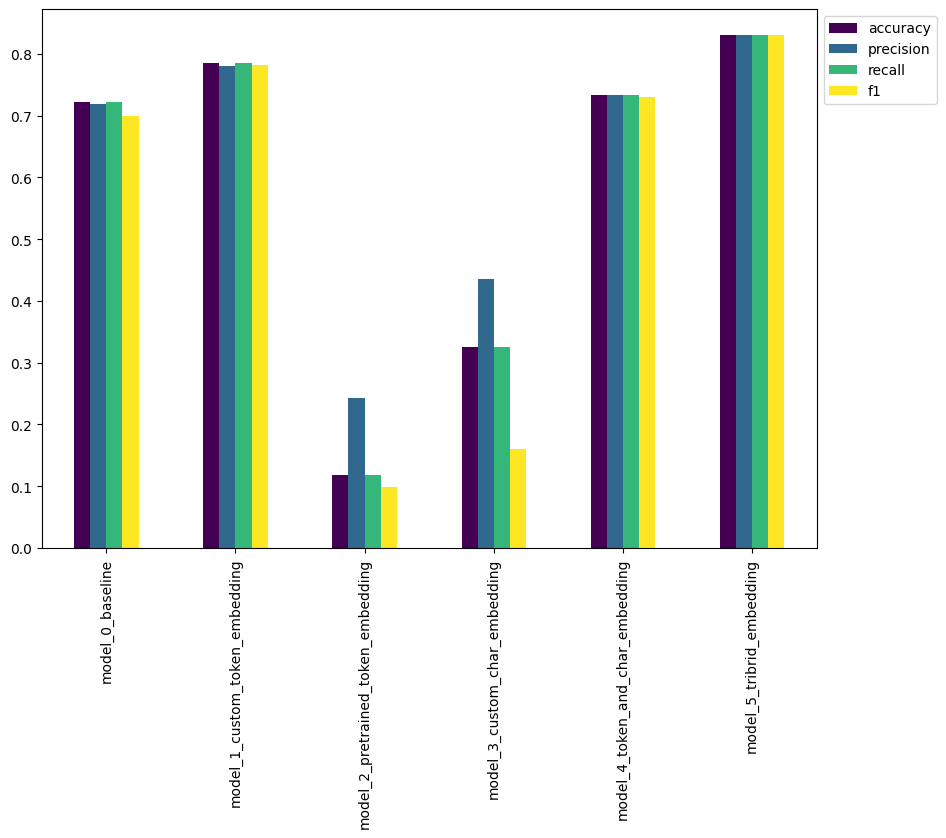

In [251]:
# Plot and compare
all_model_results.plot(kind="bar", colormap="viridis",
                       figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0))

## Save and load weights

In [255]:
model_5.save_weights("skimlit_trihybrid_model.weights.h5")

In [256]:
model_5.load_weights("skimlit_trihybrid_model.weights.h5")

In [257]:
model_5.evaluate(val_char_token_pos_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8310 - loss: 0.9389


[0.9388603568077087, 0.8309612274169922]

In [258]:
model_5.save_weights("/content/drive/MyDrive/Deep Learning/skimlit_trihybrid_model.weights.h5")

## Challenges

1. Turn the test data samples into a `tf.data.Dataset` for fast loading, then evaluate the best performing model on the test samples.

2. Find the most wrong predictions. These are the samples where the model predicted the wrong label with the highest prediction probability.

3. Make example predictions on real-world RCT abstracts from PubMed. Go to PubMed, find 3–4 abstracts from the wild, preprocess them into the same format as the training data, and use the model to predict each sentence label.

4. See the exercises and extra curriculum section on GitHub to further test your skills for this section.

Useful links:

- PubMed: https://pubmed.ncbi.nlm.nih.gov/
- Example abstracts: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/skimlit_example_abstracts.json

## Solutions

In [276]:
test_char_token_pos_dataset.element_spec

((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None)),
 TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))

In [277]:
model_5_test_results = model_5.evaluate(test_char_token_pos_dataset)

model_5_test_results

942/942 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8279 - loss: 0.9471


[0.9471205472946167, 0.8279077410697937]

In [278]:
model_5_pred_probs = model_5.predict(test_char_token_pos_dataset)

model_5_pred_probs[:5], model_5_pred_probs.shape

942/942 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step


(array([[0.3523667 , 0.07215575, 0.03657413, 0.48044762, 0.0584558 ],
        [0.34539413, 0.07187633, 0.19183041, 0.36404282, 0.02685635],
        [0.05810577, 0.02026466, 0.820627  , 0.07506886, 0.02593381],
        [0.04512698, 0.04598048, 0.6597593 , 0.05436251, 0.19477077],
        [0.04413462, 0.04917347, 0.1950295 , 0.04897577, 0.66268665]],
       dtype=float32),
 (30135, 5))

In [279]:
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)

model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([3, 3, 2, 2, 4, 4, 4, 1, 1, 0])>

In [280]:
test_labels_encoded[:10]

array([0, 4, 4, 4, 4, 4, 4, 1, 1, 0])

In [281]:
test_true_labels = test_labels_encoded

In [282]:
class_names = label_encoder.classes_
class_names

array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
      dtype=object)

In [283]:
import pandas as pd
import numpy as np

pred_df = pd.DataFrame({
    "sentence": test_sentences,
    "true_label": [class_names[i] for i in test_true_labels],
    "pred_label": [class_names[i] for i in model_5_preds.numpy()],
    "pred_conf": np.max(model_5_pred_probs, axis=1)
})

pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_df.head()

,sentence,true_label,pred_label,pred_conf,correct
0,this study analyzed liver function abnormaliti...,BACKGROUND,OBJECTIVE,0.480448,False
1,a post hoc analysis was conducted with the use...,RESULTS,OBJECTIVE,0.364043,False
2,liver function tests ( lfts ) were measured at...,RESULTS,METHODS,0.820627,False
3,survival analyses were used to assess the asso...,RESULTS,METHODS,0.659759,False
4,the percentage of patients with abnormal lfts ...,RESULTS,RESULTS,0.662687,True


In [284]:
top_wrong_preds = pred_df[pred_df["correct"] == False].sort_values(
    "pred_conf",
    ascending=False
)

top_wrong_preds.head(20)

,sentence,true_label,pred_label,pred_conf,correct
13874,symptom outcomes will be assessed and estimate...,CONCLUSIONS,METHODS,0.935794,False
16347,to evaluate the effects of the lactic acid bac...,BACKGROUND,OBJECTIVE,0.933379,False
8545,pretest-posttest .,METHODS,BACKGROUND,0.930202,False
13598,-@ % vs. fish : -@ % vs. fish + s : -@ % ; p <...,METHODS,RESULTS,0.925994,False
1827,nct@ ( clinicaltrials.gov ) .,CONCLUSIONS,BACKGROUND,0.924930,False
2388,the primary endpoint is the cumulative three-y...,RESULTS,METHODS,0.921573,False
3573,a cluster randomised trial was implemented wit...,RESULTS,METHODS,0.917785,False
835,to assess the temporal patterns of late gastro...,BACKGROUND,OBJECTIVE,0.911787,False
16633,clinicaltrials.gov identifier : nct@ .,CONCLUSIONS,BACKGROUND,0.907422,False
18720,non-diffuse-trickling '' ) .,RESULTS,BACKGROUND,0.906719,False


In [285]:
for row in top_wrong_preds.head(10).itertuples():
    print(f"True: {row.true_label}")
    print(f"Pred: {row.pred_label}")
    print(f"Confidence: {row.pred_conf:.4f}")
    print(f"Sentence: {row.sentence}")
    print("-" * 80)

True: CONCLUSIONS
Pred: METHODS
Confidence: 0.9358
Sentence: symptom outcomes will be assessed and estimates of cost-effectiveness made .
--------------------------------------------------------------------------------
True: BACKGROUND
Pred: OBJECTIVE
Confidence: 0.9334
Sentence: to evaluate the effects of the lactic acid bacterium lactobacillus salivarius on caries risk factors .
--------------------------------------------------------------------------------
True: METHODS
Pred: BACKGROUND
Confidence: 0.9302
Sentence: pretest-posttest .
--------------------------------------------------------------------------------
True: METHODS
Pred: RESULTS
Confidence: 0.9260
Sentence: -@ % vs. fish : -@ % vs. fish + s : -@ % ; p < @ ) but there were no significant differences between groups .
--------------------------------------------------------------------------------
True: CONCLUSIONS
Pred: BACKGROUND
Confidence: 0.9249
Sentence: nct@ ( clinicaltrials.gov ) .
---------------------------------

### Most wrong predictions observation

The model's most confident wrong predictions are not always random mistakes. Many of them are semantically ambiguous. For example, sentences starting with phrases like "to evaluate..." are often predicted as OBJECTIVE, even when the true label is BACKGROUND. Similarly, sentences containing phrases such as "will be assessed" may be predicted as METHODS because they describe study procedures.

This suggests that the model relies strongly on common linguistic patterns associated with each abstract section. Some errors may also come from the fact that sentence labels depend not only on the sentence itself, but also on the sentence's position and surrounding context within the abstract.

In [286]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/skimlit_example_abstracts.json

--2026-06-03 21:47:00--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/skimlit_example_abstracts.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6737 (6.6K) [text/plain]
Saving to: ‘skimlit_example_abstracts.json’

skimlit_example_abs 100%[===================>]   6.58K  --.-KB/s    in 0s      

2026-06-03 21:47:00 (55.0 MB/s) - ‘skimlit_example_abstracts.json’ saved [6737/6737]



In [287]:
import json

with open("skimlit_example_abstracts.json", "r") as f:
    example_abstracts = json.load(f)

example_abstracts

[{'abstract': 'This RCT examined the efficacy of a manualized social intervention for children with HFASDs. Participants were randomly assigned to treatment or wait-list conditions. Treatment included instruction and therapeutic activities targeting social skills, face-emotion recognition, interest expansion, and interpretation of non-literal language. A response-cost program was applied to reduce problem behaviors and foster skills acquisition. Significant treatment effects were found for five of seven primary outcome measures (parent ratings and direct child measures). Secondary measures based on staff ratings (treatment group only) corroborated gains reported by parents. High levels of parent, child and staff satisfaction were reported, along with high levels of treatment fidelity. Standardized effect size estimates were primarily in the medium and large ranges and favored the treatment group.',
  'source': 'https://pubmed.ncbi.nlm.nih.gov/20232240/',
  'details': 'RCT of a manualiz

In [288]:
len(example_abstracts)

4

In [289]:
example_abstracts[0]

{'abstract': 'This RCT examined the efficacy of a manualized social intervention for children with HFASDs. Participants were randomly assigned to treatment or wait-list conditions. Treatment included instruction and therapeutic activities targeting social skills, face-emotion recognition, interest expansion, and interpretation of non-literal language. A response-cost program was applied to reduce problem behaviors and foster skills acquisition. Significant treatment effects were found for five of seven primary outcome measures (parent ratings and direct child measures). Secondary measures based on staff ratings (treatment group only) corroborated gains reported by parents. High levels of parent, child and staff satisfaction were reported, along with high levels of treatment fidelity. Standardized effect size estimates were primarily in the medium and large ranges and favored the treatment group.',
 'source': 'https://pubmed.ncbi.nlm.nih.gov/20232240/',
 'details': 'RCT of a manualized 

In [290]:
import re

def split_chars(text):
    return " ".join(list(text))

def split_abstract_into_sentences(abstract):
    sentences = re.split(r"(?<=[.!?])\s+", abstract)
    sentences = [sentence.strip() for sentence in sentences if len(sentence.strip()) > 0]
    return sentences

In [291]:
abstract_id = 0

abstract_text = example_abstracts[abstract_id]["abstract"]
abstract_source = example_abstracts[abstract_id]["source"]
abstract_details = example_abstracts[abstract_id]["details"]

abstract_sentences = split_abstract_into_sentences(abstract_text)

abstract_sentences

['This RCT examined the efficacy of a manualized social intervention for children with HFASDs.',
 'Participants were randomly assigned to treatment or wait-list conditions.',
 'Treatment included instruction and therapeutic activities targeting social skills, face-emotion recognition, interest expansion, and interpretation of non-literal language.',
 'A response-cost program was applied to reduce problem behaviors and foster skills acquisition.',
 'Significant treatment effects were found for five of seven primary outcome measures (parent ratings and direct child measures).',
 'Secondary measures based on staff ratings (treatment group only) corroborated gains reported by parents.',
 'High levels of parent, child and staff satisfaction were reported, along with high levels of treatment fidelity.',
 'Standardized effect size estimates were primarily in the medium and large ranges and favored the treatment group.']

In [292]:
total_lines = len(abstract_sentences)

abstract_line_numbers = [i for i in range(total_lines)]
abstract_total_lines = [total_lines - 1 for _ in range(total_lines)]

abstract_line_numbers_one_hot = tf.one_hot(abstract_line_numbers, depth=15)
abstract_total_lines_one_hot = tf.one_hot(abstract_total_lines, depth=20)

abstract_chars = [split_chars(sentence) for sentence in abstract_sentences]

In [295]:
abstract_dataset = tf.data.Dataset.from_tensor_slices({
    "line_number_input": abstract_line_numbers_one_hot,
    "total_lines_input": abstract_total_lines_one_hot,
    "token_inputs": abstract_sentences,
    "char_inputs": abstract_chars
})

abstract_dataset = abstract_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

abstract_dataset.element_spec

{'line_number_input': TensorSpec(shape=(None, 15), dtype=tf.float32, name=None),
 'total_lines_input': TensorSpec(shape=(None, 20), dtype=tf.float32, name=None),
 'token_inputs': TensorSpec(shape=(None,), dtype=tf.string, name=None),
 'char_inputs': TensorSpec(shape=(None,), dtype=tf.string, name=None)}

In [296]:
abstract_pred_probs = model_5.predict(abstract_dataset)
abstract_preds = tf.argmax(abstract_pred_probs, axis=1).numpy()

abstract_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step


array([3, 2, 2, 2, 2, 2, 4, 4])

In [299]:
abstract_pred_df = pd.DataFrame({
    "line_number": abstract_line_numbers,
    "sentence": abstract_sentences,
    "pred_label": [class_names[i] for i in abstract_preds],
    "pred_conf": np.max(abstract_pred_probs, axis=1)
})

abstract_pred_df

,line_number,sentence,pred_label,pred_conf
0,0,This RCT examined the efficacy of a manualized...,OBJECTIVE,0.596733
1,1,Participants were randomly assigned to treatme...,METHODS,0.720995
2,2,Treatment included instruction and therapeutic...,METHODS,0.507704
3,3,A response-cost program was applied to reduce ...,METHODS,0.531576
4,4,Significant treatment effects were found for f...,METHODS,0.498045
5,5,Secondary measures based on staff ratings (tre...,METHODS,0.622435
6,6,"High levels of parent, child and staff satisfa...",RESULTS,0.737341
7,7,Standardized effect size estimates were primar...,RESULTS,0.513817


### Example abstract prediction observation

The model was able to assign section labels to sentences from a real-world abstract outside the original test set. The first sentence was predicted as OBJECTIVE, while sentences describing participants, treatment, and intervention procedures were mostly predicted as METHODS. Later sentences describing treatment effects and satisfaction were predicted as RESULTS.

Some predictions had relatively low confidence, which suggests that certain sentences may be semantically ambiguous or require surrounding context to classify correctly.